In [3]:
#Install/import libraries

import pandas as pd
import numpy as np
import os
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
#Upload original dataset
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving stores_sales_forecasting.csv to stores_sales_forecasting.csv
Uploaded files:
stores_sales_forecasting.csv


In [5]:
#Load dataset safely
filename = list(uploaded.keys())[0]

# Try different encodings
encodings = ["utf-8", "latin1", "cp1252"]

df = None

for enc in encodings:
    try:
        df = pd.read_csv(filename, encoding=enc)
        print(f"Dataset loaded successfully using encoding: {enc}")
        break
    except UnicodeDecodeError:
        print(f"Failed with encoding: {enc}")

if df is None:
    raise ValueError("Could not read the CSV file.")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Failed with encoding: utf-8
Dataset loaded successfully using encoding: latin1
Shape: (2121, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


***Inspect original dataset***

In [6]:
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [7]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2121, 21)

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype:

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


***Find important columns***

In [9]:
for col in df.columns:
    print(repr(col))

'Row ID'
'Order ID'
'Order Date'
'Ship Date'
'Ship Mode'
'Customer ID'
'Customer Name'
'Segment'
'Country'
'City'
'State'
'Postal Code'
'Region'
'Product ID'
'Category'
'Sub-Category'
'Product Name'
'Sales'
'Quantity'
'Discount'
'Profit'


***Clean column names***

In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


***Convert date***

In [11]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

print("Invalid dates:", df["order_date"].isna().sum())

print("Date range:")
print(df["order_date"].min())
print(df["order_date"].max())

Invalid dates: 0
Date range:
2014-01-06 00:00:00
2017-12-30 00:00:00


***Check Sales***

In [12]:
df["sales"] = pd.to_numeric(
    df["sales"],
    errors="coerce"
)

print("Missing sales:", df["sales"].isna().sum())
print("Negative sales:", (df["sales"] < 0).sum())

print(df["sales"].describe())

Missing sales: 0
Negative sales: 0
count    2121.000000
mean      349.834887
std       503.179145
min         1.892000
25%        47.040000
50%       182.220000
75%       435.168000
max      4416.174000
Name: sales, dtype: float64


***Check Quantity / Orders***

In [13]:
df["quantity"] = pd.to_numeric(
    df["quantity"],
    errors="coerce"
)

print(df["quantity"].describe())
print("Missing quantity:", df["quantity"].isna().sum())

count    2121.000000
mean        3.785007
std         2.251620
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: quantity, dtype: float64
Missing quantity: 0


***Create 3 branches***

In [14]:
# Check available geographic columns

possible_location_columns = [
    "city",
    "state",
    "region",
    "postal_code"
]

for col in possible_location_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].dropna().unique()[:20])


city:
['Henderson' 'Fort Lauderdale' 'Los Angeles' 'Philadelphia' 'Orem'
 'Richardson' 'Houston' 'New Albany' 'Troy' 'Chicago' 'Memphis' 'Columbia'
 'Minneapolis' 'New York City' 'Aurora' 'Seattle' 'Wilmington'
 'Bloomington' 'Roseville' 'Newark']

state:
['Kentucky' 'Florida' 'California' 'Pennsylvania' 'Utah' 'Texas' 'Indiana'
 'New York' 'Illinois' 'Tennessee' 'South Carolina' 'Minnesota' 'Colorado'
 'Washington' 'Delaware' 'Ohio' 'Wisconsin' 'Michigan' 'New Jersey'
 'Connecticut']

region:
['South' 'West' 'East' 'Central']

postal_code:
[42420 33311 90032 19140 84057 75080 77041 47150 12180 90004 60610 38109
 77070 29203 55407 10009 80013 10035 98103 19805]


In [15]:
if "region" in df.columns:

    regions = df["region"].dropna().unique()

    print("Available regions:", regions)

    if len(regions) >= 3:
        branch_map = {
            regions[0]: "B001",
            regions[1]: "B002",
            regions[2]: "B003"
        }

        df["branch_id"] = df["region"].map(branch_map)

    else:
        print("Less than 3 regions found.")

Available regions: ['South' 'West' 'East' 'Central']


In [16]:
if "branch_id" not in df.columns or df["branch_id"].isna().all():

    if "state" in df.columns:
        locations = df["state"].dropna().unique()

    elif "city" in df.columns:
        locations = df["city"].dropna().unique()

    else:
        locations = []

    print("Available locations:", locations[:20])

    if len(locations) < 3:
        raise ValueError(
            "Dataset does not contain enough geographic groups "
            "to create 3 branches."
        )

    selected_locations = locations[:3]

    location_to_branch = {
        selected_locations[0]: "B001",
        selected_locations[1]: "B002",
        selected_locations[2]: "B003"
    }

    location_column = (
        "state" if "state" in df.columns else "city"
    )

    df["branch_id"] = df[location_column].map(
        location_to_branch
    )

print(df["branch_id"].value_counts())

branch_id
B002    707
B003    601
B001    332
Name: count, dtype: int64


***Keep only 3 branches***

In [17]:
df = df[df["branch_id"].isin(["B001", "B002", "B003"])].copy()

print("Branches:")
print(df["branch_id"].value_counts())

Branches:
branch_id
B002    707
B003    601
B001    332
Name: count, dtype: int64


***Daily aggregation***

In [18]:
daily_sales = (
    df.groupby(["order_date", "branch_id"])
      .agg(
          sales=("sales", "sum"),
          orders=("quantity", "sum")
      )
      .reset_index()
)

daily_sales.head()

,order_date,branch_id,sales,orders
0,2014-01-06,B001,2573.820,9
1,2014-01-10,B001,51.940,1
2,2014-01-11,B003,9.940,2
3,2014-01-13,B001,545.940,6
4,2014-01-13,B002,333.999,3


***Rename date***

In [19]:
daily_sales = daily_sales.rename(
    columns={"order_date": "date"}
)

daily_sales["date"] = pd.to_datetime(daily_sales["date"])

daily_sales = daily_sales.sort_values(
    ["branch_id", "date"]
).reset_index(drop=True)

display(daily_sales.head())

,date,branch_id,sales,orders
0,2014-01-06,B001,2573.820,9
1,2014-01-10,B001,51.940,1
2,2014-01-13,B001,545.940,6
3,2014-01-20,B001,1106.540,7
4,2014-01-21,B001,25.248,3


***Create promotion feature***

In [20]:
if "discount" in df.columns:

    discount_daily = (
        df.groupby(["order_date", "branch_id"])["discount"]
          .max()
          .reset_index()
    )

    discount_daily = discount_daily.rename(
        columns={
            "order_date": "date",
            "discount": "promotion_value"
        }
    )

    daily_sales = daily_sales.merge(
        discount_daily,
        on=["date", "branch_id"],
        how="left"
    )

    daily_sales["promotion"] = (
        daily_sales["promotion_value"] > 0
    ).astype(int)

    daily_sales = daily_sales.drop(
        columns=["promotion_value"]
    )

else:
    daily_sales["promotion"] = 0

print(daily_sales["promotion"].value_counts())

promotion
1    698
0    388
Name: count, dtype: int64


***Create holiday flag***

In [21]:
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

# Example documented holiday dates
holiday_dates = pd.to_datetime([
    "2015-12-25",
    "2015-11-26",
    "2016-12-25",
    "2016-11-24",
    "2017-12-25",
    "2017-11-23",
    "2018-12-25",
    "2018-11-22"
])

daily_sales["holiday"] = (
    daily_sales["date"].isin(holiday_dates)
).astype(int)

print("Holiday days:", daily_sales["holiday"].sum())

Holiday days: 12


***Create store_open***

In [22]:
daily_sales["store_open"] = 1

print(
    daily_sales["store_open"].value_counts()
)

store_open
1    1086
Name: count, dtype: int64


***Create temperature***

In [23]:
np.random.seed(42)

# Seasonal temperature pattern
day_of_year = daily_sales["date"].dt.dayofyear

daily_sales["temperature"] = (
    20
    + 10 * np.sin(
        2 * np.pi * day_of_year / 365
    )
    + np.random.normal(
        0, 2, len(daily_sales)
    )
)

daily_sales["temperature"] = (
    daily_sales["temperature"]
    .round(1)
)

daily_sales.head()

,date,branch_id,sales,orders,promotion,holiday,store_open,temperature
0,2014-01-06,B001,2573.820,9,0,0,1,22.0
1,2014-01-10,B001,51.940,1,0,0,1,21.4
2,2014-01-13,B001,545.940,6,0,0,1,23.5
3,2014-01-20,B001,1106.540,7,0,0,1,26.4
4,2014-01-21,B001,25.248,3,1,0,1,23.1


***Final schema and Final data types***

In [24]:
required_columns = [
    "date",
    "branch_id",
    "sales",
    "orders",
    "promotion",
    "holiday",
    "store_open",
    "temperature"
]

final_df = daily_sales[required_columns].copy()

print(final_df.columns.tolist())
final_df["date"] = pd.to_datetime(final_df["date"])

final_df["branch_id"] = final_df["branch_id"].astype(str)

final_df["sales"] = final_df["sales"].astype(float)

final_df["orders"] = final_df["orders"].astype(int)

final_df["promotion"] = final_df["promotion"].astype(int)

final_df["holiday"] = final_df["holiday"].astype(int)

final_df["store_open"] = final_df["store_open"].astype(int)

final_df["temperature"] = final_df["temperature"].astype(float)

print(final_df.dtypes)

['date', 'branch_id', 'sales', 'orders', 'promotion', 'holiday', 'store_open', 'temperature']
date           datetime64[ns]
branch_id              object
sales                 float64
orders                  int64
promotion               int64
holiday                 int64
store_open              int64
temperature           float64
dtype: object


***Validate basic data***

In [25]:
print("Rows:", len(final_df))
print("Branches:", final_df["branch_id"].nunique())

print(
    "Branches:",
    sorted(final_df["branch_id"].unique())
)

print(
    "Date range:",
    final_df["date"].min(),
    "to",
    final_df["date"].max()
)

print(
    "Missing values:\n",
    final_df.isnull().sum()
)

print(
    "Duplicate rows:",
    final_df.duplicated().sum()
)

print(
    "Negative sales:",
    (final_df["sales"] < 0).sum()
)

Rows: 1086
Branches: 3
Branches: ['B001', 'B002', 'B003']
Date range: 2014-01-06 00:00:00 to 2017-12-30 00:00:00
Missing values:
 date           0
branch_id      0
sales          0
orders         0
promotion      0
holiday        0
store_open     0
temperature    0
dtype: int64
Duplicate rows: 0
Negative sales: 0


***Check daily branch uniqueness***

In [26]:
duplicates = final_df.duplicated(
    subset=["date", "branch_id"]
).sum()

print(
    "Duplicate date + branch combinations:",
    duplicates
)

Duplicate date + branch combinations: 0


***Check branches***

In [27]:
branch_summary = (
    final_df.groupby("branch_id")
    .agg(
        rows=("date", "count"),
        total_sales=("sales", "sum"),
        average_sales=("sales", "mean"),
        total_orders=("orders", "sum")
    )
    .round(2)
)

display(branch_summary)

,rows,total_sales,average_sales,total_orders
branch_id,,,,
B001,247,117298.68,474.89,1291
B002,459,252612.74,550.35,2696
B003,380,208291.20,548.13,2214


***Visualize sales and Weekend effect check***

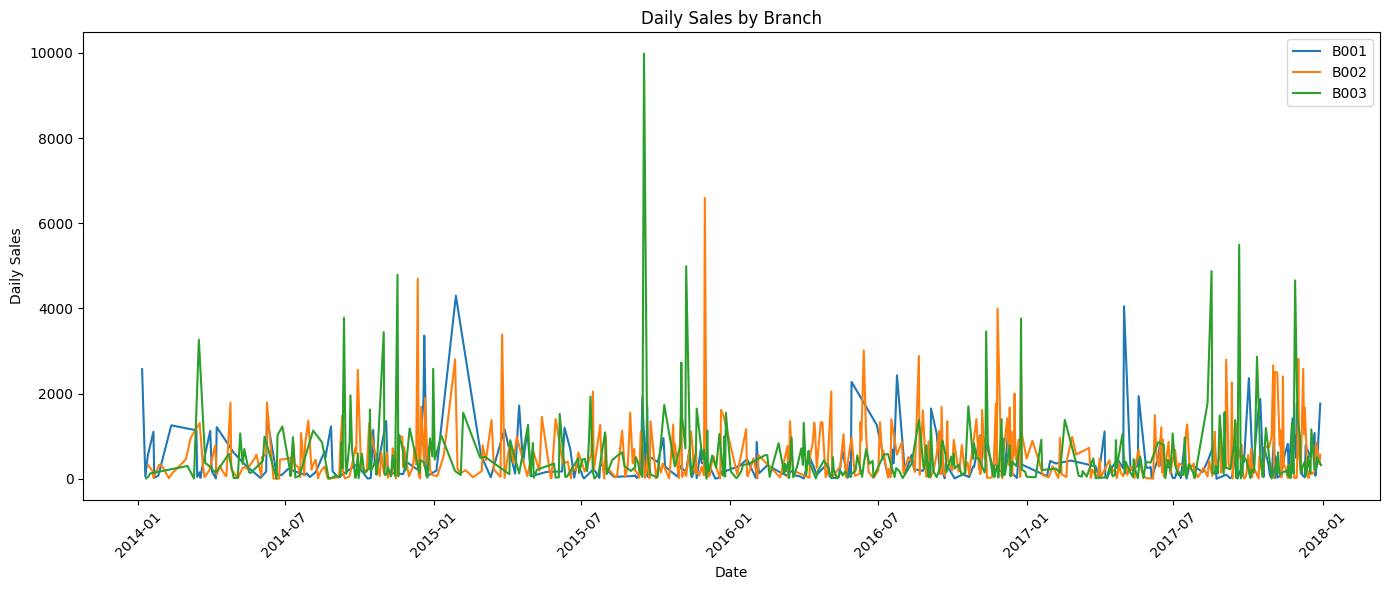

,sales
day_of_week,
Monday,625.834182
Tuesday,476.613655
Wednesday,612.475902
Thursday,550.287507
Friday,563.857054
Saturday,466.953805
Sunday,464.265788


In [28]:
plt.figure(figsize=(14, 6))

for branch in sorted(final_df["branch_id"].unique()):

    branch_data = final_df[
        final_df["branch_id"] == branch
    ]

    plt.plot(
        branch_data["date"],
        branch_data["sales"],
        label=branch
    )

plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Daily Sales by Branch")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

final_df["day_of_week"] = final_df["date"].dt.day_name()

weekday_summary = (
    final_df.groupby("day_of_week")["sales"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

display(weekday_summary)

***Promotion effect and Save final CSV***

In [29]:
promotion_summary = (
    final_df.groupby("promotion")["sales"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

display(promotion_summary)

os.makedirs("ai-sales-forecasting/data", exist_ok=True)

csv_path = "ai-sales-forecasting/data/sample_sales.csv"

final_df.to_csv(
    csv_path,
    index=False
)

print("Saved:", csv_path)

,count,mean,sum
promotion,,,
0,388,327.10,126915.42
1,698,646.54,451287.21


Saved: ai-sales-forecasting/data/sample_sales.csv


***Test CSV loading and Create project folders***

In [30]:
test_df = pd.read_csv(
    "ai-sales-forecasting/data/sample_sales.csv"
)

print("CSV loaded successfully!")
print("Shape:", test_df.shape)

display(test_df.head())

folders = [
    "ai-sales-forecasting/data",
    "ai-sales-forecasting/src",
    "ai-sales-forecasting/docs",
    "ai-sales-forecasting/reports",
    "ai-sales-forecasting/reports/figures",
    "ai-sales-forecasting/notebooks",
    "ai-sales-forecasting/tests"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

CSV loaded successfully!
Shape: (1086, 9)


,date,branch_id,sales,orders,promotion,holiday,store_open,temperature,day_of_week
0,2014-01-06,B001,2573.820,9,0,0,1,22.0,Monday
1,2014-01-10,B001,51.940,1,0,0,1,21.4,Friday
2,2014-01-13,B001,545.940,6,0,0,1,23.5,Monday
3,2014-01-20,B001,1106.540,7,0,0,1,26.4,Monday
4,2014-01-21,B001,25.248,3,1,0,1,23.1,Tuesday


Project structure created.


***Create data_dictionary.md and Create data_validation.py***

In [33]:
data_dictionary = """
# Data Dictionary

## Dataset
`data/sample_sales.csv`

This dataset is an adapted daily sales dataset created from the provided
source retail sales dataset. The source data was aggregated by date and
assigned to three branch identifiers for the restaurant forecasting
prototype.

## Columns

| Column | Type | Required | Unit | Allowed Values | Missing Values | Meaning |
|---|---|---|---|---|---|---|
| date | date | Yes | YYYY-MM-DD | Valid dates | Not allowed | Business date |
| branch_id | string | Yes | N/A | B001, B002, B003 | Not allowed | Restaurant branch identifier |
| sales | float | Yes | Currency units | >= 0 | Not allowed | Daily sales target |
| orders | integer | Yes | Count | >= 0 | Not allowed | Daily order/quantity count |
| promotion | integer | Yes | Binary | 0 or 1 | Not allowed | Promotion indicator |
| holiday | integer | Yes | Binary | 0 or 1 | Not allowed | Holiday indicator |
| store_open | integer | Yes | Binary | 0 or 1 | Not allowed | Whether the branch was open |
| temperature | float | Optional | Degrees | Numeric | Not allowed | Weather-related temperature feature |

## Data Limitations

The source dataset is a retail sales dataset rather than actual restaurant
transaction data. Therefore, the final dataset is an adapted prototype
dataset and must not be presented as real restaurant performance data.

The branch IDs are created for the forecasting prototype.

The holiday indicator and temperature values are synthetic/documented
features because equivalent source fields were not available.

## Validation Rules

- Required columns must exist.
- Dates must be valid.
- Sales cannot be negative.
- Branch ID must be valid.
- Forecast horizon must be greater than zero.
- Forecast horizon must not exceed the documented maximum.
- Empty branch selections must be rejected.
- Invalid sales values must not silently be converted to zero.
"""

with open(
    "ai-sales-forecasting/docs/data_dictionary.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(data_dictionary)

print("data_dictionary.md created.")
validation_code = '''
import pandas as pd

REQUIRED_COLUMNS = [
    "date",
    "branch_id",
    "sales",
    "orders",
    "promotion",
    "holiday",
    "store_open",
    "temperature"
]

VALID_BRANCHES = ["B001", "B002", "B003"]

MIN_HORIZON = 1
MAX_HORIZON = 30


def validate_input(df, branch_id, horizon):

    # Check required columns
    missing_columns = [
        col for col in REQUIRED_COLUMNS
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    # Validate branch
    if branch_id not in VALID_BRANCHES:
        raise ValueError(
            f"Unknown branch_id: {branch_id}"
        )

    # Validate horizon
    if horizon < MIN_HORIZON:
        raise ValueError(
            "Forecast horizon must be greater than 0."
        )

    if horizon > MAX_HORIZON:
        raise ValueError(
            f"Forecast horizon cannot exceed {MAX_HORIZON} days."
        )

    data = df.copy()

    # Validate dates
    data["date"] = pd.to_datetime(
        data["date"],
        errors="coerce"
    )

    if data["date"].isna().any():
        raise ValueError(
            "Invalid or missing date values found."
        )

    # Validate sales
    data["sales"] = pd.to_numeric(
        data["sales"],
        errors="coerce"
    )

    if data["sales"].isna().any():
        raise ValueError(
            "Missing or invalid sales values found."
        )

    if (data["sales"] < 0).any():
        raise ValueError(
            "Sales cannot contain negative values."
        )

    # Filter branch
    filtered = data[
        data["branch_id"] == branch_id
    ].copy()

    if filtered.empty:
        raise ValueError(
            f"No data available for branch: {branch_id}"
        )

    # Sort
    filtered = filtered.sort_values(
        "date"
    ).reset_index(drop=True)

    return filtered
'''

with open(
    "ai-sales-forecasting/src/data_validation.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(validation_code)

print("data_validation.py created.")

data_dictionary.md created.
data_validation.py created.


***Test validation and Test unknown branch***

In [34]:
import sys

sys.path.append(
    "ai-sales-forecasting/src"
)

from data_validation import validate_input

valid_data = validate_input(
    final_df,
    "B001",
    7
)

print("VALID INPUT TEST PASSED")
print(valid_data.head())

try:
    validate_input(
        final_df,
        "B999",
        7
    )

except ValueError as e:
    print("TEST PASSED:")
    print(e)

VALID INPUT TEST PASSED
        date branch_id     sales  orders  promotion  holiday  store_open  \
0 2014-01-06      B001  2573.820       9          0        0           1   
1 2014-01-10      B001    51.940       1          0        0           1   
2 2014-01-13      B001   545.940       6          0        0           1   
3 2014-01-20      B001  1106.540       7          0        0           1   
4 2014-01-21      B001    25.248       3          1        0           1   

   temperature day_of_week  
0         22.0      Monday  
1         21.4      Friday  
2         23.5      Monday  
3         26.4      Monday  
4         23.1     Tuesday  
TEST PASSED:
Unknown branch_id: B999


***Test horizon = 0 and Test horizon > 30***

In [38]:
try:
    validate_input(
        final_df,
        "B001",
        0
    )

except ValueError as e:
    print("TEST PASSED:")
    print(e)




TEST PASSED:
Forecast horizon must be greater than 0.


In [39]:
try:
    validate_input(
        final_df,
        "B001",
        31
    )

except ValueError as e:
    print("TEST PASSED:")
    print(e)

TEST PASSED:
Forecast horizon cannot exceed 30 days.


***Test negative sales and Test missing date***

In [40]:
test_negative = final_df.copy()

test_negative.loc[
    test_negative.index[0],
    "sales"
] = -100

try:
    validate_input(
        test_negative,
        "B001",
        7
    )

except ValueError as e:
    print("TEST PASSED:")
    print(e)



TEST PASSED:
Sales cannot contain negative values.


In [41]:
test_missing_date = final_df.copy()

test_missing_date.loc[
    test_missing_date.index[0],
    "date"
] = pd.NaT

try:
    validate_input(
        test_missing_date,
        "B001",
        7
    )

except ValueError as e:
    print("TEST PASSED:")
    print(e)

TEST PASSED:
Invalid or missing date values found.


***Create quality report automatically***

In [42]:
row_count = len(final_df)

date_min = final_df["date"].min()
date_max = final_df["date"].max()

branch_count = final_df["branch_id"].nunique()

missing_values = final_df.isnull().sum()

duplicate_rows = final_df.duplicated().sum()

duplicate_date_branch = final_df.duplicated(
    subset=["date", "branch_id"]
).sum()

negative_sales = (
    final_df["sales"] < 0
).sum()

quality_report = f"""
# Data Quality Report

## Dataset

`data/sample_sales.csv`

## Overview

- Row count: {row_count}
- Date range: {date_min.date()} to {date_max.date()}
- Branch count: {branch_count}
- Branch IDs: {", ".join(sorted(final_df["branch_id"].unique()))}

## Missing Values

| Column | Missing |
|---|---:|
"""

for column, count in missing_values.items():
    quality_report += f"| {column} | {count} |\\n"

quality_report += f"""

## Duplicates

- Duplicate complete rows: {duplicate_rows}
- Duplicate date + branch combinations: {duplicate_date_branch}

## Sales Validation

- Negative sales values: {negative_sales}

## Validation Decisions

- Required schema verified.
- Dates parsed and validated.
- Sales values checked for missing and negative values.
- Branch IDs restricted to B001, B002 and B003.
- Forecast horizon approved from 1 to 30 days.
- Invalid sales are rejected rather than silently converted to zero.

## Dataset Limitation

The source data is a retail sales dataset rather than real restaurant
transaction data. It has been adapted for a restaurant sales forecasting
prototype. Branch IDs, holiday indicators and temperature values are
created/documented for the prototype.

Therefore, results must not be presented as actual restaurant business
performance.

## Status

Dataset preparation and validation completed for Zara's assigned role.
"""

with open(
    "ai-sales-forecasting/reports/data_quality_report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(quality_report)

print("data_quality_report.md created.")

data_quality_report.md created.


***Final dataset preview and Final verification***

In [44]:
display(
    final_df.head(10)
)
print("=" * 60)
print("ZARA DATA VALIDATION FINAL CHECK")
print("=" * 60)

checks = {
    "CSV exists":
        os.path.exists(
            "ai-sales-forecasting/data/sample_sales.csv"
        ),

    "Data dictionary exists":
        os.path.exists(
            "ai-sales-forecasting/docs/data_dictionary.md"
        ),

    "Validation module exists":
        os.path.exists(
            "ai-sales-forecasting/src/data_validation.py"
        ),

    "Quality report exists":
        os.path.exists(
            "ai-sales-forecasting/reports/data_quality_report.md"
        ),

    "Three branches":
        final_df["branch_id"].nunique() >= 3,

    "No negative sales":
        (final_df["sales"] < 0).sum() == 0,

    "No missing required values":
        final_df[required_columns].isnull().sum().sum() == 0,

    "No duplicate date/branch":
        final_df.duplicated(
            subset=["date", "branch_id"]
        ).sum() == 0
}

for check, result in checks.items():
    print(
        f"{'PASS' if result else 'FAIL'}: {check}"
    )

,date,branch_id,sales,orders,promotion,holiday,store_open,temperature,day_of_week
0,2014-01-06,B001,2573.820,9,0,0,1,22.0,Monday
1,2014-01-10,B001,51.940,1,0,0,1,21.4,Friday
2,2014-01-13,B001,545.940,6,0,0,1,23.5,Monday
3,2014-01-20,B001,1106.540,7,0,0,1,26.4,Monday
4,2014-01-21,B001,25.248,3,1,0,1,23.1,Tuesday
5,2014-01-26,B001,75.240,6,0,0,1,23.9,Sunday
6,2014-02-11,B001,1256.220,6,0,0,1,29.8,Tuesday
7,2014-03-14,B001,1139.920,4,0,0,1,31.0,Friday
8,2014-03-15,B001,45.696,3,1,0,1,28.6,Saturday
9,2014-03-18,B001,153.120,5,1,0,1,30.8,Tuesday


ZARA DATA VALIDATION FINAL CHECK
PASS: CSV exists
PASS: Data dictionary exists
PASS: Validation module exists
PASS: Quality report exists
PASS: Three branches
PASS: No negative sales
PASS: No missing required values
PASS: No duplicate date/branch


***Create ZIP for handoff and Download***

In [45]:
shutil.make_archive(
    "zara_data_validation",
    "zip",
    "ai-sales-forecasting"
)

print("ZIP created: zara_data_validation.zip")
from google.colab import files

files.download(
    "zara_data_validation.zip"
)

ZIP created: zara_data_validation.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>